In [1]:
# ==============================================================================
# Prevelance Model VAE
# ==============================================================================

import os
import sys

import numpy as np 
import geopandas as gpd
import jax
import jax.numpy as jnp
from jax import random

import numpyro 
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

import matplotlib.pyplot as plt

import time
import pickle

sys.path.append(os.path.pardir)
from aggGP import exp_sq_kernel
from aggVAE import vae_decoder


In [2]:
def prev_model_vae_aggr(args, tested_positive = None):

    x = args["x"] #(2618,2)
    n_specimens_lo = args["n_specimens_lo"] #num_tests : ()
    n_specimens_hi = args["n_specimens_hi"] 
    
    out_dims = args["out_dims"] #58 , Decoder Output size
    predict = args["predict"]

    n_hi_regions = n_specimens_hi.shape[0] #49
    
    # random effect
    decoder_params =args["decoder_params"]
    z_dim, h_dim = decoder_params[0][0].shape # 40, 50
    z = numpyro.sample("z", dist.Normal(jnp.zeros(z_dim), jnp.ones(z_dim))) #(40,)
    dec_init_fn, dec_apply_fn = vae_decoder(h_dim, out_dims) # Instantiate decoder
    vae_aggr = numpyro.deterministic("vae_aggr", dec_apply_fn(decoder_params, z)) #(*,58)
    s = numpyro.sample("sigma", dist.HalfNormal(50)) #(,)
    vae = numpyro.deterministic("vae", s * vae_aggr) #(58,)


    # Fixed effects 
    b0 = numpyro.sample("b0", dist.Normal(0,1)) #(,)
    lp = b0 + vae #(58,)
    theta = numpyro.deterministic("theta", jax.nn.sigmoid(lp)) #(9,)

    if not predict:
        total_tested_cases = jnp.concatenate([n_specimens_lo, n_specimens_hi], axis = 0)
        # Add NaN values to n_positive to accomodate unavailable data for high resolution. 
        # n_positive : [low_res_pos ... nan for high_res ...]
        tested_positive = jnp.pad(tested_positive, (0, n_hi_regions),constant_values = 0.0) #[3762.  484. ... , 0,0,0]
        tested_positive = jnp.where(tested_positive == 0, jnp.nan, tested_positive)# [3762.  484. ... , nan,nan,nan]
        tested_positive_mask = ~jnp.isnan(tested_positive) # [True, True, ...., False, False, False]

        #We use numpyro.handlers.mask to make sure we can account for NaN values for observations
        with numpyro.handlers.mask(mask=tested_positive_mask): 
            n_positive_obs = numpyro.sample(
                "positive_cases", 
                dist.BinomialLogits(total_count = total_tested_cases, logits = lp), 
                obs = tested_positive
            ) #(58,)

    else:
        total_tested_cases = jnp.concatenate([n_specimens_lo, n_specimens_hi], axis = 0)
        n_positive_obs = numpyro.sample(
            "positive_cases", 
            dist.BinomialLogits(total_count = total_tested_cases, logits = lp), 
            obs = tested_positive
        ) 


    return n_positive_obs

In [3]:
# ------------------------------ Load variables ------------------------------ #
# root directory
var_dir = "../data/processed"
# Lat/Lon Values of artificial grid
x = np.load(os.path.join(var_dir,"lat_lon_x.npy")) #(2618,2)
# Low regional data
pol_pt_lo = np.load(os.path.join(var_dir,"low","pol_pt_lo.npy")) #(9,2618)
pt_which_pol_lo = np.load(os.path.join(var_dir,"low","pt_which_pol_lo.npy")) #(2618,)
# High regional data 
pol_pt_hi = np.load(os.path.join(var_dir,"high","pol_pt_hi.npy")) #(49, 2618,)
pt_which_pol_hi = np.load(os.path.join(var_dir,"high","pt_which_pol_hi.npy")) #(2618,)
# Dataframes
df_lo = gpd.read_file(os.path.join(var_dir, "low", "us_census_divisions","us_census_divisions.shp"))
df_hi = gpd.read_file(os.path.join(var_dir, "high", "us_state_divisions","us_state_divisions.shp"))

In [4]:
# ---------------------------- Load Decoder Model ---------------------------- #
with open("../model_weights/aggVAE_Dec_e20_h53_z48", "rb") as file:
    vae_params = pickle.load(file)

encoder_params = vae_params["encoder$params"]
decoder_params = vae_params["decoder$params"]

In [5]:
# ---------------------------- Arguments to Model ---------------------------- #
args = {
    #"n_low_obs" : df_lo.tot_cases, #observarions <- This is passed as y
    "n_specimens_lo" : jnp.array(df_lo.tot_specs),
    "n_specimens_hi" : jnp.array(df_hi.tot_specs),  
    "x" : jnp.array(x),
    "gp_kernel" : exp_sq_kernel,
    "jitter" : 1e-4,
    "noise" : 1e-4,
    "M_lo" : pol_pt_lo,
    "M_hi" : pol_pt_hi,

    # VAE training
    "rng_key": random.PRNGKey(5),
    "num_epochs": 20, 
    "learning_rate": 0.0005, 
    "batch_size": 100, 
    "hidden_dim": 6, 
    "z_dim": 3, 
    "num_train": 100,
    "num_test":100,
    "vae_var": 1,

    # NN Weights
    "decoder_params" : decoder_params,
    "out_dims" : df_lo.shape[0] + df_hi.shape[0], #58
    
    # To handle Predictions since np.nans giving us issues
    "predict" : False,

    # Set to True only if you want to see VAE Aggr GP results before running MCMC
    "check_vae_samples" : True
}

2024-09-27 12:13:39.372870: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.3 which is older than the PTX compiler version 12.6.68. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## MCMC Training

In [6]:
# -------------------------- Run MCMC on aggVAEPrev -------------------------- #
rng_key, rng_key_predict = random.split(random.PRNGKey(6))

start = time.time()
mcmc = MCMC(
    NUTS(prev_model_vae_aggr),
    num_warmup = 2000,
    num_samples = 1000,
)
mcmc.run(rng_key, args, tested_positive = jnp.array(df_lo.tot_cases))
t_elapsed_sec = time.time() - start
t_elapsed_min = t_elapsed_sec / 60

print(f"time taken : {t_elapsed_min} (mins)")

sample: 100%|██████████| 3000/3000 [08:43<00:00,  5.73it/s, 1023 steps of size 2.42e-04. acc. prob=0.92]


time taken : 8.79194370508194 (mins)


In [7]:
prev_samples = mcmc.get_samples()
mcmc.print_summary(exclude_deterministic=False)


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
          b0     -1.63      0.29     -1.61     -2.04     -1.17     12.57      1.05
       sigma     10.25      1.08      9.95      8.95     12.27      8.96      1.11
    theta[0]      0.06      0.00      0.06      0.06      0.06    870.52      1.00
    theta[1]      0.32      0.01      0.32      0.30      0.33    928.80      1.00
    theta[2]      0.03      0.00      0.03      0.03      0.03   1827.31      1.00
    theta[3]      0.14      0.00      0.14      0.14      0.14    979.11      1.00
    theta[4]      0.14      0.00      0.14      0.14      0.14   1029.02      1.00
    theta[5]      0.15      0.00      0.15      0.14      0.15    953.62      1.00
    theta[6]      0.40      0.00      0.40      0.40      0.41    924.23      1.00
    theta[7]      0.30      0.00      0.30      0.29      0.31    794.92      1.00
    theta[8]      0.06      0.00      0.06      0.06      0.06    752.84      1.00
   

In [8]:
n_lo = df_lo.shape[0]
n_hi = df_hi.shape[0]

ss = numpyro.diagnostics.summary(mcmc.get_samples(group_by_chain=True))
r = np.mean(ss['vae_aggr']['n_eff'])
print("Average ESS for all aggVAE effects : " + str(round(r)))

ess_lo = np.mean(ss["vae_aggr"]["n_eff"][0:n_lo])
r_hat_lo = np.max(ss["vae_aggr"]["r_hat"][0:n_lo])

ess_hi = np.mean(ss["vae_aggr"]["n_eff"][n_lo:n_lo + n_hi])
r_hat_hi = np.max(ss["vae_aggr"]["r_hat"][n_lo : n_lo + n_hi])

print(f"Average ESS for all aggVAE-low effects : {round(ess_lo)}")
print(f"Max r_hat for all aggVAE-low : {round(r_hat_lo,2)}")

print(f"Average ESS for all aggVAE-high effects : {round(ess_hi)}")
print(f"Max r_hat for all aggVAE-high : {round(r_hat_hi,2)}")


Average ESS for all aggVAE effects : 10
Average ESS for all aggVAE-low effects : 12
Max r_hat for all aggVAE-low : 1.1399999856948853
Average ESS for all aggVAE-high effects : 9
Max r_hat for all aggVAE-high : 2.0899999141693115


In [9]:
prev_samples.keys()

dict_keys(['b0', 'sigma', 'theta', 'vae', 'vae_aggr', 'z'])

In [10]:
# calculate Prevelance values : Need to check if this is correct
df_lo["prev"] = df_lo.tot_cases / df_lo.tot_specs
df_hi["prev"] = df_hi.tot_cases / df_hi.tot_specs

In [11]:
# posterior predictive 1
args["predict"] = True
prev_posterior_predictive_vae = Predictive(prev_model_vae_aggr, prev_samples)(random.PRNGKey(1), args)

theta_samps_vae_aggr = prev_posterior_predictive_vae["theta"]
theta_mean_vae_aggr = theta_samps_vae_aggr.mean(axis = 0)
bci_vae_aggr_25 = np.quantile(theta_samps_vae_aggr,0.25, axis = 0)
bci_vae_aggr_75 = np.quantile(theta_samps_vae_aggr,0.75, axis = 0)
df_lo["theta_vae_aggr"] = theta_mean_vae_aggr[0:n_lo]
df_hi["theta_vae_aggr"] = theta_mean_vae_aggr[n_lo:n_lo + n_hi]

theta_observed_lo = df_lo["prev"]
theta_observed_hi = df_hi["prev"]
theta_observed = np.hstack([theta_observed_lo, theta_observed_hi])
theta_vae_aggr = theta_mean_vae_aggr

_max = np.max([theta_observed, theta_vae_aggr])
_min = np.min([theta_observed, theta_vae_aggr])



In [12]:
df_lo

,area,tot_specs,tot_cases,geometry,prev,theta_vae_aggr
0,East North Central,62901,3762,"MULTIPOLYGON (((-91.50504 40.19993, -91.50666 ...",0.059808,0.059831
1,East South Central,1532,484,"MULTIPOLYGON (((-88.45324 30.20648, -88.44905 ...",0.315927,0.316056
2,Middle Atlantic,80827,2266,"MULTIPOLYGON (((-75.55064 39.63791, -75.5472 3...",0.028035,0.028081
3,Mountain,42251,5961,"POLYGON ((-103.00196 36.90957, -103.0022 36.71...",0.141085,0.141060
4,New England,20954,2964,"MULTIPOLYGON (((-71.58023 41.20484, -71.5773 4...",0.141453,0.141240
5,Pacific,48541,7167,"MULTIPOLYGON (((-122.41847 37.86176, -122.4184...",0.147648,0.147610
6,South Atlantic,12874,5185,"MULTIPOLYGON (((-81.87468 24.56361, -81.88775 ...",0.402750,0.402836
7,West North Central,9762,2948,"POLYGON ((-91.42663 40.37199, -91.42944 40.370...",0.301987,0.301615
8,West South Central,14849,873,"MULTIPOLYGON (((-90.66162 29.07226, -90.65212 ...",0.058792,0.058715


Text(0.5, 1.0, 'Low: Estimated prevalence (aggregated VAE)')

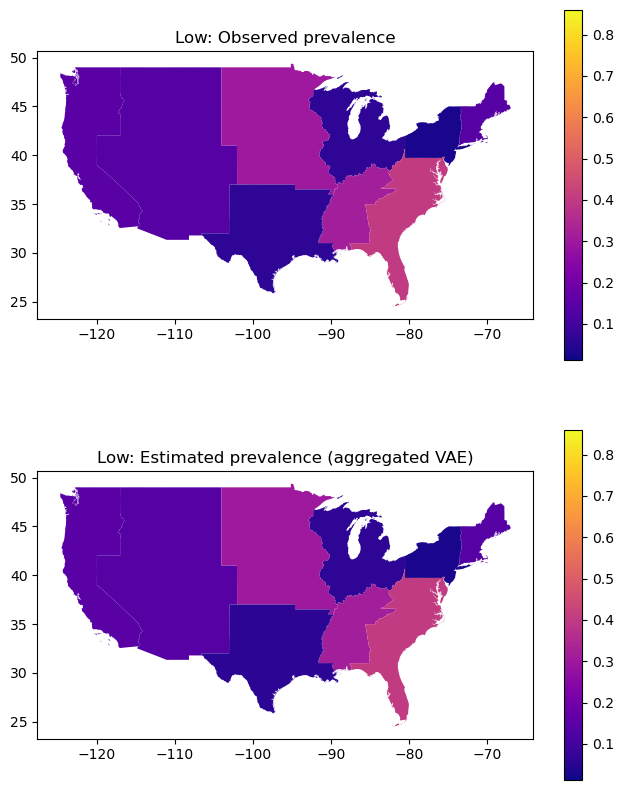

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(8,10))

df_lo.plot(column="prev", ax=ax[0], legend=True, cmap='plasma', vmin=_min, vmax =_max)
df_lo.plot(column="theta_vae_aggr", ax=ax[1], legend=True, cmap='plasma', vmin=_min, vmax =_max)

ax[0].set_title( 'Low: Observed prevalence')
ax[1].set_title( 'Low: Estimated prevalence (aggregated VAE)')

In [14]:
import seaborn as sns

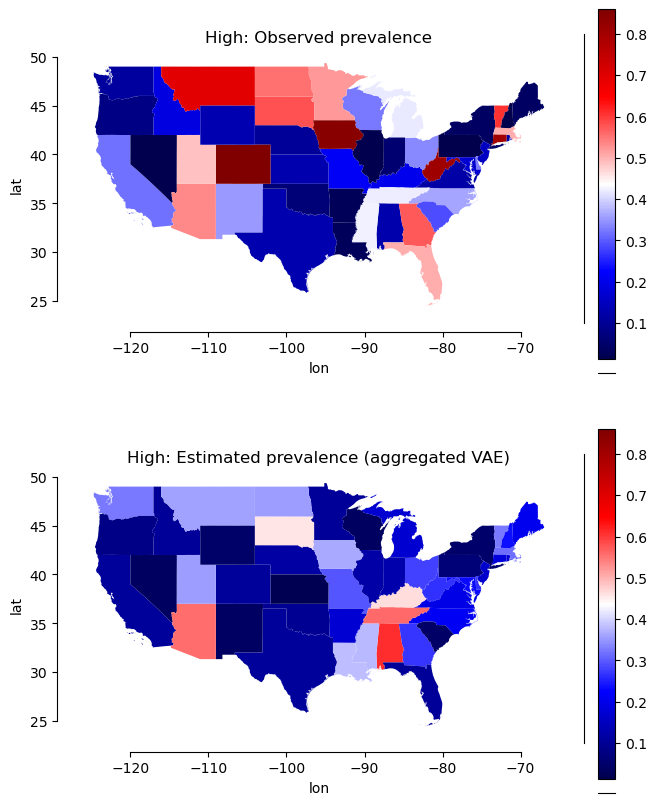

In [15]:
fig, ax = plt.subplots(2,1, figsize=(8,10))


df_hi.plot(column="prev", ax=ax[0], legend=True, cmap='seismic', vmin=_min, vmax =_max)
df_hi.plot(column="theta_vae_aggr", ax=ax[1], legend=True, cmap='seismic', vmin=_min, vmax =_max)

ax[0].set_title( 'High: Observed prevalence')
ax[1].set_title( 'High: Estimated prevalence (aggregated VAE)')
ax[0].set_xlabel("lon"); ax[0].set_ylabel("lat")
ax[1].set_xlabel("lon"); ax[1].set_ylabel("lat")
fig.savefig("../tmp/results2.png")
sns.despine(offset=10, trim=True)

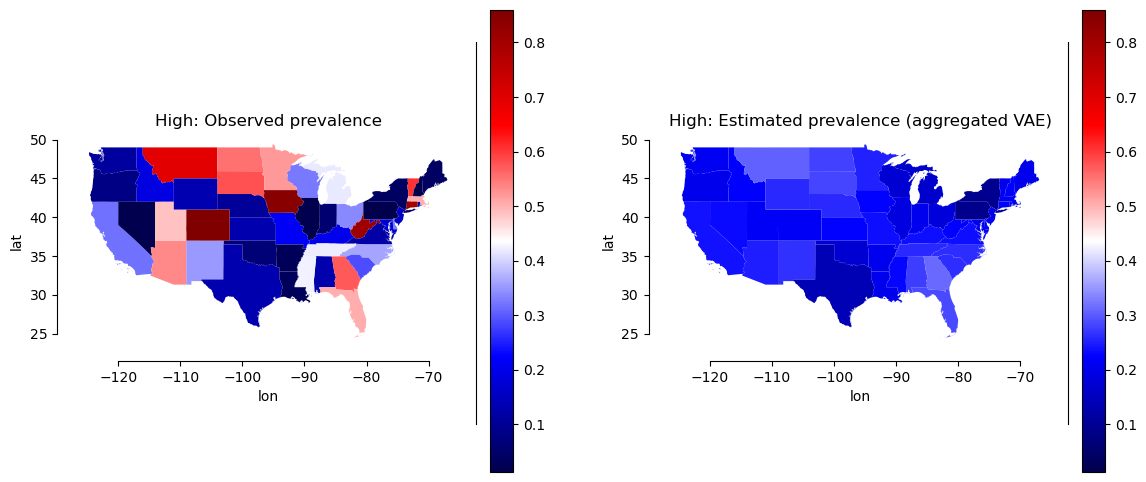

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))


df_hi.plot(column="prev", ax=ax[0], legend=True, cmap='seismic', vmin=_min, vmax =_max)
df_hi.plot(column="theta_vae_aggr", ax=ax[1], legend=True, cmap='seismic', vmin=_min, vmax =_max)

ax[0].set_title( 'High: Observed prevalence')
ax[1].set_title( 'High: Estimated prevalence (aggregated VAE)')
ax[0].set_xlabel("lon"); ax[0].set_ylabel("lat")
ax[1].set_xlabel("lon"); ax[1].set_ylabel("lat")
fig.savefig("../tmp/results.png")
sns.despine(offset=10, trim=True)

In [16]:
df_hi

,index,area,tot_specs,tot_cases,geometry,prev,theta_vae_aggr
0,0,Nebraska,3132,326,"POLYGON ((-104.05351 41.15726, -104.05267 41.2...",0.104087,0.259353
1,1,Washington,9710,1077,"MULTIPOLYGON (((-122.32834 48.02134, -122.3217...",0.110917,0.210186
2,2,New Mexico,3090,1088,"POLYGON ((-109.05017 31.48, -109.04984 31.4995...",0.352104,0.264501
3,3,South Dakota,499,290,"POLYGON ((-104.0577 44.99743, -104.05021 44.99...",0.581162,0.283523
4,4,Texas,4082,531,"POLYGON ((-106.64548 31.89867, -106.64084 31.9...",0.130083,0.138093
5,5,California,10547,3376,"MULTIPOLYGON (((-118.60338 33.4781, -118.59878...",0.320091,0.239010
6,6,Kentucky,509,104,"MULTIPOLYGON (((-89.40565 36.52816, -89.39868 ...",0.204322,0.235183
7,7,Ohio,3448,1163,"MULTIPOLYGON (((-82.73571 41.60336, -82.7188 4...",0.337297,0.181218
8,8,Alabama,172,22,"MULTIPOLYGON (((-88.04374 30.51742, -88.03661 ...",0.127907,0.275924
9,9,Georgia,3227,1854,"POLYGON ((-85.60516 34.98468, -85.55259 34.984...",0.574527,0.312848


Text(0.5, 1.0, 'High Resolution Regions')

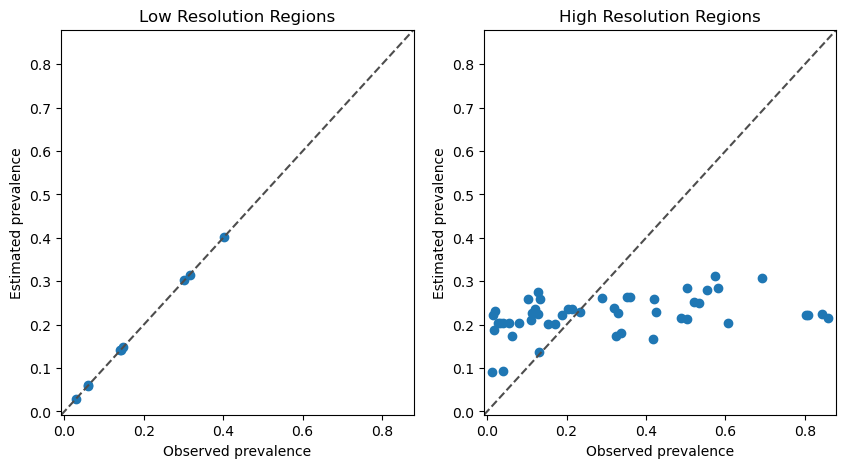

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].scatter(df_lo.prev, df_lo.theta_vae_aggr)
ax[0].set_ylim(_min-0.02, _max+0.02)
ax[0].set_xlim(_min-0.02, _max+0.02)
ax[0].axline((1, 1), slope=1, ls="--", c=".3")
ax[0].set_xlabel("Observed prevalence")
ax[0].set_ylabel("Estimated prevalence")
ax[0].set_title("Low Resolution Regions")

ax[1].scatter(df_hi.prev, df_hi.theta_vae_aggr)
ax[1].set_ylim(_min-0.02, _max+0.02)
ax[1].set_xlim(_min-0.02, _max+0.02)
ax[1].axline((1, 1), slope=1, ls="--", c=".3")
ax[1].set_xlabel("Observed prevalence")
ax[1].set_ylabel("Estimated prevalence")
ax[1].set_title("High Resolution Regions")